# SAXS Tensor Tomography — Method Comparison

Compares four reconstruction methods on the same frogbone dataset, all converted to the
same representation: one scalar volume per q-direction `(K, X, Y, Z)`.

| Section | Method | Library |
|---------|--------|---------|
| 1 | FBP | smartt |
| 2 | NearestNeighbor + LBFGS | mumott |
| 3 | SphericalHarmonics + LBFGS → projected to NN | mumott |
| 4 | GaussianKernels + LBFGS → projected to NN | mumott |
| 5 | Side-by-side comparison + missing-cone visualisation | — |
| 6 | IsoNet missing-wedge correction | smartt |

All mumott reconstructions use the same optimiser settings so comparisons are fair.

Before the comparison section all reconstructions are **spherically cropped** to the
largest inscribed sphere (diameter = largest multiple of 8 ≤ min(X,Y,Z)) so every method
is evaluated on the same spatial region.

In [1]:
try:
    from mumott.data_handling import DataContainer
except:
    !sh ../scripts/setup.sh
    !pip install --upgrade coverage pytest-cov

wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
Obtaining file:///myhome/smartt
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Using cached mumott-2.2-py3-none-any.whl.metadata (1.5 kB)
  Using cached colorcet-3.2.1-py3-none-any.whl.metadata (6.3 kB)
  Using cached colorspacious-1.1.2-py2.py3-none-any.whl.metadata (3.6 kB)
  Using cached cuda_core-1.0.1-cp310-cp310-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (3.2 kB)
  Using cached numba_cuda-0.30.4-cp310-cp310-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (3.8 kB)
  Using cached backports_strenum-1.3.1-py3-none-any.whl.metadata

In [52]:
import lovely_tensors as lt
lt.monkey_patch()

In [1]:
import sys
sys.path.insert(0, '/myhome/smartt')

import pathlib
import numpy as np
import torch
import matplotlib.pyplot as plt

from mumott.data_handling import DataContainer
from mumott.methods.basis_sets import SphericalHarmonics, GaussianKernels, NearestNeighbor
from mumott.methods.projectors import SAXSProjectorCUDA, SAXSProjector
from mumott.methods.residual_calculators import GradientResidualCalculator
from mumott.optimization.loss_functions import SquaredLoss
from mumott.optimization.optimizers import LBFGS
from mumott.optimization.regularizers import Laplacian
from mumott.core.probed_coordinates import ProbedCoordinates

from smartt.saxs_fbp import fibonacci_hemisphere, saxs_fbp_reconstruction, saxs_gd_reconstruction

# ── Parameters ────────────────────────────────────────────────────────────────
# DATA_PATH        = '/myhome/data/smartt/shared/frogbone/dataset_qbin_0009.h5'
DATA_PATH = '/myhome/data/smartt/shared/b411/dataset_b411R_inf_1_0.220_1.900.h5'
# DATA_PATH        = '/myhome/data/smartt/shared/missing_wedge/full_data_zenodo/data/data_set_1.h5'
K                = 30      # number of q-directions (Fibonacci hemisphere)
HALF_SPACE       = 'y'     # y>0 hemisphere to match goniometer frame
LBFGS_MAXITER    = 20
LAPLACIAN_WEIGHT = 1e-1
SH_ELL_MAX       = 8

# ── Cache settings ─────────────────────────────────────────────────────────────
# mumott optimisations are saved as .npy files (keyed by method + K) so they
# can be skipped on subsequent runs.  Set force_reload=True to rerun from scratch.
CACHE_DIR    = pathlib.Path(DATA_PATH).parent / "saxs_comparison"
force_reload = False

CACHE_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Cache directory: {CACHE_DIR}')
print(f'force_reload: {force_reload}')

AttributeError: module 'numba.cuda.types' has no attribute 'NPDatetime'

In [54]:
dc = DataContainer(DATA_PATH, nonfinite_replacement_value=0)
dc.geometry.full_circle_covered = False

geometry = dc.geometry

print('data shape    :', dc.data.shape, '  (N, J, K_det, M)')
print('volume_shape  :', geometry.volume_shape)
print('n_projections :', len(dc.projections))

y_directions = fibonacci_hemisphere(K, half_space=HALF_SPACE)
print(f'\ny_directions shape: {y_directions.shape}  (K, 3)')

INFO:Rotation matrices were loaded from the input file.
INFO:Sample geometry loaded from file.
INFO:Detector geometry loaded from file.
data shape    : (266, 111, 86, 8)   (N, J, K_det, M)
volume_shape  : [ 86 111  86]
n_projections : 266

y_directions shape: (30, 3)  (K, 3)


## 1. smartt FBP Reconstruction

For each of the K q-directions the scalar sinogram is built via a GPU einsum over the
arc-fraction projection matrix, then inverted with ramp-filtered backprojection (ASTRA BP3D).

In [55]:
ball_threshold = 0.2

recon_fbp, y_dirs, nn_helper = saxs_fbp_reconstruction(
    dc=dc,
    k_fibonacci=K,
    filter_type='hann',
    n_projection_samples=64,
    device=device,
    verbose=True,
    return_matrix=True,
    projection_method='ball',
    ball_threshold=ball_threshold,
    half_space=HALF_SPACE,
)


# recon_fbp, y_dirs, nn_helper = saxs_gd_reconstruction(
#     dc=dc,
#     k_fibonacci=K,
#     n_iterations=300,
#     lr=0.5,
#     n_projection_samples=64,
#     device=device,
#     verbose=True,
#     return_matrix=True,
#     projection_method="ball",
#     ball_threshold=ball_threshold,
#     half_space=HALF_SPACE,
# )
recon_fbp_np = recon_fbp.cpu().numpy()   # (K, X, Y, Z)
print(f'\nFBP shape  : {recon_fbp_np.shape}')
print(f'value range: [{recon_fbp_np.min():.3e}, {recon_fbp_np.max():.3e}]')

INFO:Building projection matrix on GPU: K=30, n_samples=64, method=ball
INFO:Moving data to cuda...


SAXS FBP: 100%|██████████| 30/30 [00:00<00:00, 97.84dir/s, n_sub=112]



FBP shape  : (30, 86, 111, 86)
value range: [-1.572e+04, 6.944e+03]


## 2. mumott NearestNeighbor Reconstruction

Uses the same K Fibonacci directions as the FBP.  Each coefficient `C[x,y,z,k]` directly
represents the scattering intensity at direction `y_k` — no basis conversion needed.

In [56]:
# Build the shared mumott projector once (fast — geometry setup only).
# Always constructed so it is available if any method needs to optimise.
projector_mumott = (
    SAXSProjector(geometry) if torch.cuda.is_available() else SAXSProjector(geometry)
)

_nn_cache = CACHE_DIR / f'mumott_nn_K{K}.npy'

if not force_reload and _nn_cache.exists():
    print(f'Loading NN coefficients from cache: {_nn_cache}')
    coeffs_nn = np.load(_nn_cache)
else:
    basis_nn = NearestNeighbor(
        directions=y_directions,
        probed_coordinates=geometry.probed_coordinates,
    )
    rc_nn   = GradientResidualCalculator(data_container=dc, basis_set=basis_nn, projector=projector_mumott)
    loss_nn = SquaredLoss(rc_nn)
    loss_nn.add_regularizer('laplacian', Laplacian(), regularization_weight=LAPLACIAN_WEIGHT)
    opt_nn  = LBFGS(loss_nn, maxiter=LBFGS_MAXITER)
    result_nn = opt_nn.optimize()
    coeffs_nn = result_nn['x']                    # (X, Y, Z, K)
    np.save(_nn_cache, coeffs_nn)
    print(f'Saved NN coefficients → {_nn_cache}')

print(f'coeffs_nn shape: {coeffs_nn.shape}')

Loading NN coefficients from cache: /myhome/data/smartt/shared/b411/saxs_comparison/mumott_nn_K30.npy
coeffs_nn shape: (86, 111, 86, 30)


In [57]:
recon_nn = np.moveaxis(coeffs_nn, -1, 0)   # (K, X, Y, Z)
print(f'NN reconstruction shape: {recon_nn.shape}')

NN reconstruction shape: (30, 86, 111, 86)


## 3. mumott SphericalHarmonics Reconstruction → projected to NN

Optimises a band-limited SH expansion (`ell_max=6`, C=28 coefficients with Friedel symmetry),
then evaluates it at the K Fibonacci directions to obtain the same `(K, X, Y, Z)` layout.

The evaluation uses the SH basis matrix `B[k,c] = Y_c(y_k)` computed via
`_get_projection_matrix` — the same internal function used by mumott's `generate_map`.

In [58]:
_sh_cache = CACHE_DIR / f'mumott_sh_ell{SH_ELL_MAX}_K{K}.npy'

# basis_sh is always instantiated: it is needed for the transfer step (cell below)
# regardless of whether the coefficients come from cache or from optimisation.
basis_sh = SphericalHarmonics(
    ell_max=SH_ELL_MAX,
    probed_coordinates=geometry.probed_coordinates,
)
print(f'SH basis: ell_max={SH_ELL_MAX}, n_coefficients={len(basis_sh)}')

if not force_reload and _sh_cache.exists():
    print(f'Loading SH coefficients from cache: {_sh_cache}')
    coeffs_sh = np.load(_sh_cache)
else:
    rc_sh   = GradientResidualCalculator(data_container=dc, basis_set=basis_sh, projector=projector_mumott)
    loss_sh = SquaredLoss(rc_sh)
    loss_sh.add_regularizer('laplacian', Laplacian(), regularization_weight=LAPLACIAN_WEIGHT)
    opt_sh  = LBFGS(loss_sh, maxiter=LBFGS_MAXITER)
    result_sh = opt_sh.optimize()
    coeffs_sh = result_sh['x']                    # (X, Y, Z, C)
    np.save(_sh_cache, coeffs_sh)
    print(f'Saved SH coefficients → {_sh_cache}')

print(f'coeffs_sh shape: {coeffs_sh.shape}')

SH basis: ell_max=8, n_coefficients=45
Loading SH coefficients from cache: /myhome/data/smartt/shared/b411/saxs_comparison/mumott_sh_ell8_K30.npy
coeffs_sh shape: (86, 111, 86, 45)


In [59]:
# Build evaluation matrix: B[k, c] = Y_c(y_k)  shape (K, C)
pc_eval = ProbedCoordinates()
pc_eval.vector = y_directions[:, np.newaxis, np.newaxis, :]   # (K, 1, 1, 3)
eval_sh = basis_sh._get_projection_matrix(pc_eval)[:, 0, 0, :]  # (K, C)

recon_sh  = np.einsum('xyzc, kc -> kxyz', coeffs_sh, eval_sh)  # (K, X, Y, Z)
print(f'SH→NN reconstruction shape: {recon_sh.shape}')

SH→NN reconstruction shape: (30, 86, 111, 86)


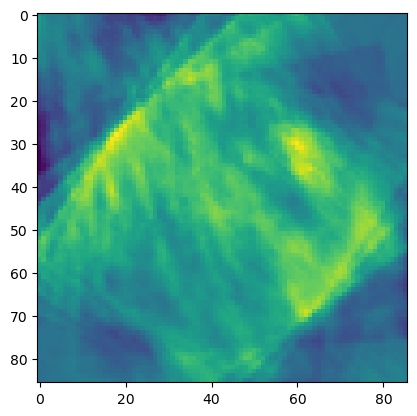

In [60]:
plt.imshow(recon_sh[1][:, 20])

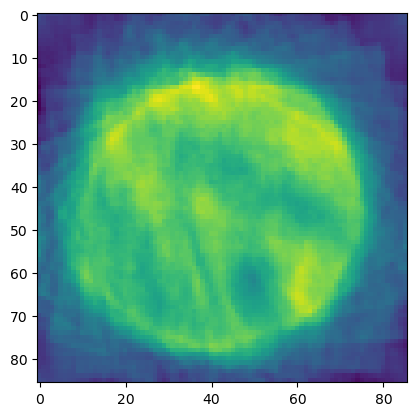

In [61]:
plt.imshow(coeffs_sh[:, 20, :, 0])

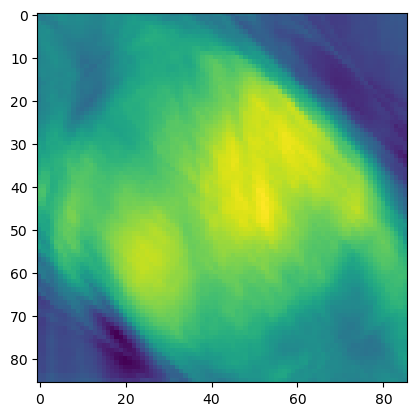

In [62]:
plt.imshow(recon_sh[1][:, :].sum(axis=1))

## 3.2. smartt NAF Reconstruction with SH → projected to NN

In [63]:
from smartt.saxs_naf import saxs_naf_reconstruction, evaluate_models, plot_rsm_direction

_naf_cache = CACHE_DIR / f'mumott_naf_ell{SH_ELL_MAX}_K{K}.npy'

# basis_sh is always instantiated: it is needed for the transfer step (cell below)
# regardless of whether the coefficients come from cache or from optimisation.
basis_sh = SphericalHarmonics(
    ell_max=SH_ELL_MAX,
    probed_coordinates=geometry.probed_coordinates,
)
print(f'SH basis: ell_max={SH_ELL_MAX}, n_coefficients={len(basis_sh)}')

if not force_reload and _naf_cache.exists():
    print(f'Loading SH coefficients from cache: {_naf_cache}')
    coeffs_naf = np.load(_naf_cache)
else:
    res = saxs_naf_reconstruction(dc, ell_max=8, n_iterations=2000, batch_size=100, reg_weight_tv=0., reg_weight_sh=1e-6)
    coeffs_naf = res["reconstruction"]   
    np.save(_naf_cache, coeffs_naf)
    print(f'Saved SH coefficients → {_naf_cache}')

# res = saxs_naf_reconstruction(dc, ell_max=8, n_iterations=1000, batch_size=100, reg_weight_tv=2e-5, reg_weight_sh=1e-6)
# coeffs_naf = res["reconstruction"]   
# np.save(_naf_cache, coeffs_naf)
# print(f'Saved SH coefficients → {_naf_cache}')
print(f'coeffs_naf shape: {coeffs_naf.shape}')

# Build evaluation matrix: B[k, c] = Y_c(y_k)  shape (K, C)
pc_eval = ProbedCoordinates()
pc_eval.vector = y_directions[:, np.newaxis, np.newaxis, :]   # (K, 1, 1, 3)
eval_sh = basis_sh._get_projection_matrix(pc_eval)[:, 0, 0, :]  # (K, C)

recon_naf  = np.einsum('xyzc, kc -> kxyz', coeffs_naf, eval_sh)  # (K, X, Y, Z)
print(f'SH→NN reconstruction shape: {recon_naf.shape}')

SH basis: ell_max=8, n_coefficients=45
Loading SH coefficients from cache: /myhome/data/smartt/shared/b411/saxs_comparison/mumott_naf_ell8_K30.npy
coeffs_naf shape: (86, 111, 86, 45)
SH→NN reconstruction shape: (30, 86, 111, 86)


In [64]:
# with torch.no_grad():
#     c = res["model"]()
#     sh_raw = float(res["model"].sh_regularization(c))
#     tv_raw = float(res["model"].tv_regularization(c))
#     print(f"data loss:  7.675e+07")
#     print(f"SH  (raw):  {sh_raw:.3e}  → weight for 1%: {7.675e5 / sh_raw:.2e}")
#     print(f"TV  (raw):  {tv_raw:.3e}  → weight for 1%: {7.675e5 / tv_raw:.2e}")


## 4. mumott GaussianKernels Reconstruction → projected to NN

Same pipeline as SH but using isotropic Gaussian kernels on the sphere.  The default
`grid_scale=4` places kernels at a Kurihara mesh resolution of ~4 points per 90°.

In [65]:
_gk_cache = CACHE_DIR / f'mumott_gk_K{K}.npy'

basis_gk = GaussianKernels(
    probed_coordinates=geometry.probed_coordinates,
)
print(f'GK basis: n_kernels={len(basis_gk)}')

if not force_reload and _gk_cache.exists():
    print(f'Loading GK coefficients from cache: {_gk_cache}')
    coeffs_gk = np.load(_gk_cache)
else:
    rc_gk   = GradientResidualCalculator(data_container=dc, basis_set=basis_gk, projector=projector_mumott)
    loss_gk = SquaredLoss(rc_gk)
    loss_gk.add_regularizer('laplacian', Laplacian(), regularization_weight=LAPLACIAN_WEIGHT)
    opt_gk  = LBFGS(loss_gk, maxiter=LBFGS_MAXITER)
    result_gk = opt_gk.optimize()
    coeffs_gk = result_gk['x']                    # (X, Y, Z, C_gk)
    np.save(_gk_cache, coeffs_gk)
    print(f'Saved GK coefficients → {_gk_cache}')

print(f'coeffs_gk shape: {coeffs_gk.shape}')

GK basis: n_kernels=50
Loading GK coefficients from cache: /myhome/data/smartt/shared/b411/saxs_comparison/mumott_gk_K30.npy
coeffs_gk shape: (86, 111, 86, 50)


In [66]:
eval_gk = basis_gk._get_projection_matrix(pc_eval)[:, 0, 0, :]  # (K, C_gk)
recon_gk  = np.einsum('xyzc, kc -> kxyz', coeffs_gk, eval_gk)  # (K, X, Y, Z)
print(f'GK→NN reconstruction shape: {recon_gk.shape}')

GK→NN reconstruction shape: (30, 86, 111, 86)


In [67]:
# ## Spherical crop — apply to all methods before comparison
# # Crops each (K, X, Y, Z) reconstruction to (K, d, d, d) and zeros the sphere
# # exterior, so all methods are compared on the same spatial region.
# # d = (min(X, Y, Z) // 8) * 8  — for frogbone (65, 82, 65) this gives d = 64.
# from smartt.saxs_isonet.preprocess import spherical_crop, make_sphere_mask

# _t, _, SPHERE_D = spherical_crop(torch.from_numpy(recon_fbp_np), cube_size=None)
# recon_fbp_np = _t.numpy()

# recon_nn = spherical_crop(torch.from_numpy(recon_nn.astype(np.float32)), cube_size=SPHERE_D)[0].numpy()
# recon_sh = spherical_crop(torch.from_numpy(recon_sh.astype(np.float32)), cube_size=SPHERE_D)[0].numpy()
# recon_gk = spherical_crop(torch.from_numpy(recon_gk.astype(np.float32)), cube_size=SPHERE_D)[0].numpy()

# sphere_mask_np = make_sphere_mask(SPHERE_D)   # (d, d, d) bool — for masked percentiles
# print(f'Sphere diameter d={SPHERE_D}; all reconstructions now {recon_fbp_np.shape}')

## 5. Comparison

All four reconstructions are now in `(K, X, Y, Z)` float32 arrays with the same K Fibonacci
q-directions.  The following panels compare them using the same colour scale.

- **5.1** Mean intensity orthoslices
- **5.2** Single q-direction volume slices
- **5.3** Difference maps relative to FBP
- **5.4** Missing-cone visualisation in Fourier space

In [68]:
reconstructions = {
    # 'FBP (smartt)':               recon_fbp_np,
    'NAF (smartt)':               recon_naf,
    # 'NearestNeighbor (mumott)':   recon_nn,
    'SphericalHarmonics (mumott)': recon_sh,
    'GaussianKernels (mumott)':   recon_gk,
}

vol_shape = recon_fbp_np.shape[1:]
mid_x, mid_y, mid_z = [s // 2 for s in vol_shape]
print('Volume shape:', vol_shape)
print(f'Central slices: x={mid_x}, y={mid_y}, z={mid_z}')

Volume shape: (86, 111, 86)
Central slices: x=43, y=55, z=43


### 5.1 Mean intensity orthoslices

Colour scale is fixed to the [2nd, 98th] percentile of the FBP mean volume so all panels
are directly comparable.

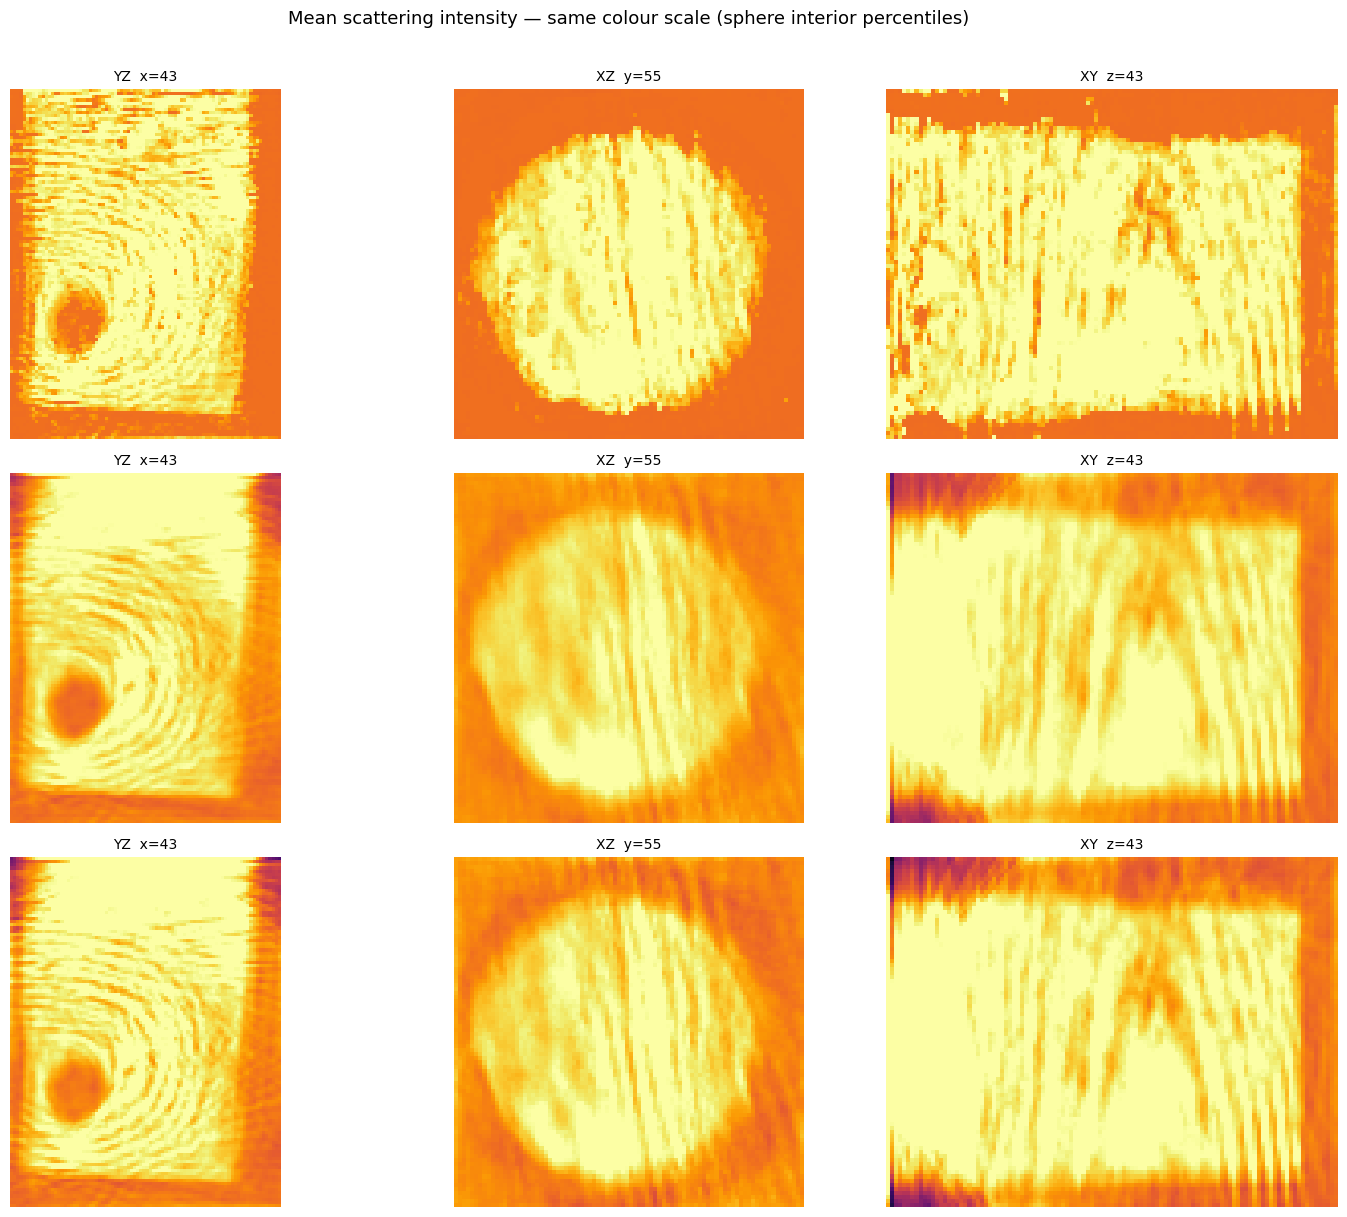

In [69]:
mean_fbp = recon_fbp_np.mean(axis=0)
# Use sphere interior for percentiles so exterior zeros don't compress the colour scale.
vmin, vmax = np.percentile(mean_fbp, [2, 98])

n_methods = len(reconstructions)
fig, axes = plt.subplots(n_methods, 3, figsize=(15, 4 * n_methods))

for row, (name, recon) in enumerate(reconstructions.items()):
    mean_vol = recon.mean(axis=0)
    slices   = [mean_vol[mid_x, :, :], mean_vol[:, mid_y, :], mean_vol[:, :, mid_z]]
    titles   = [f'YZ  x={mid_x}', f'XZ  y={mid_y}', f'XY  z={mid_z}']
    for col, (sl, title) in enumerate(zip(slices, titles)):
        im = axes[row, col].imshow(sl, cmap='inferno', vmin=vmin, vmax=vmax)
        axes[row, col].axis('off')
        axes[row, col].set_title(title, fontsize=10)
    axes[row, 0].set_ylabel(name, fontsize=9)

plt.suptitle('Mean scattering intensity — same colour scale (sphere interior percentiles)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 5.2 Single q-direction volume slices

Each panel shows one reconstructed direction k.  Change `K_INSPECT` to explore other directions.

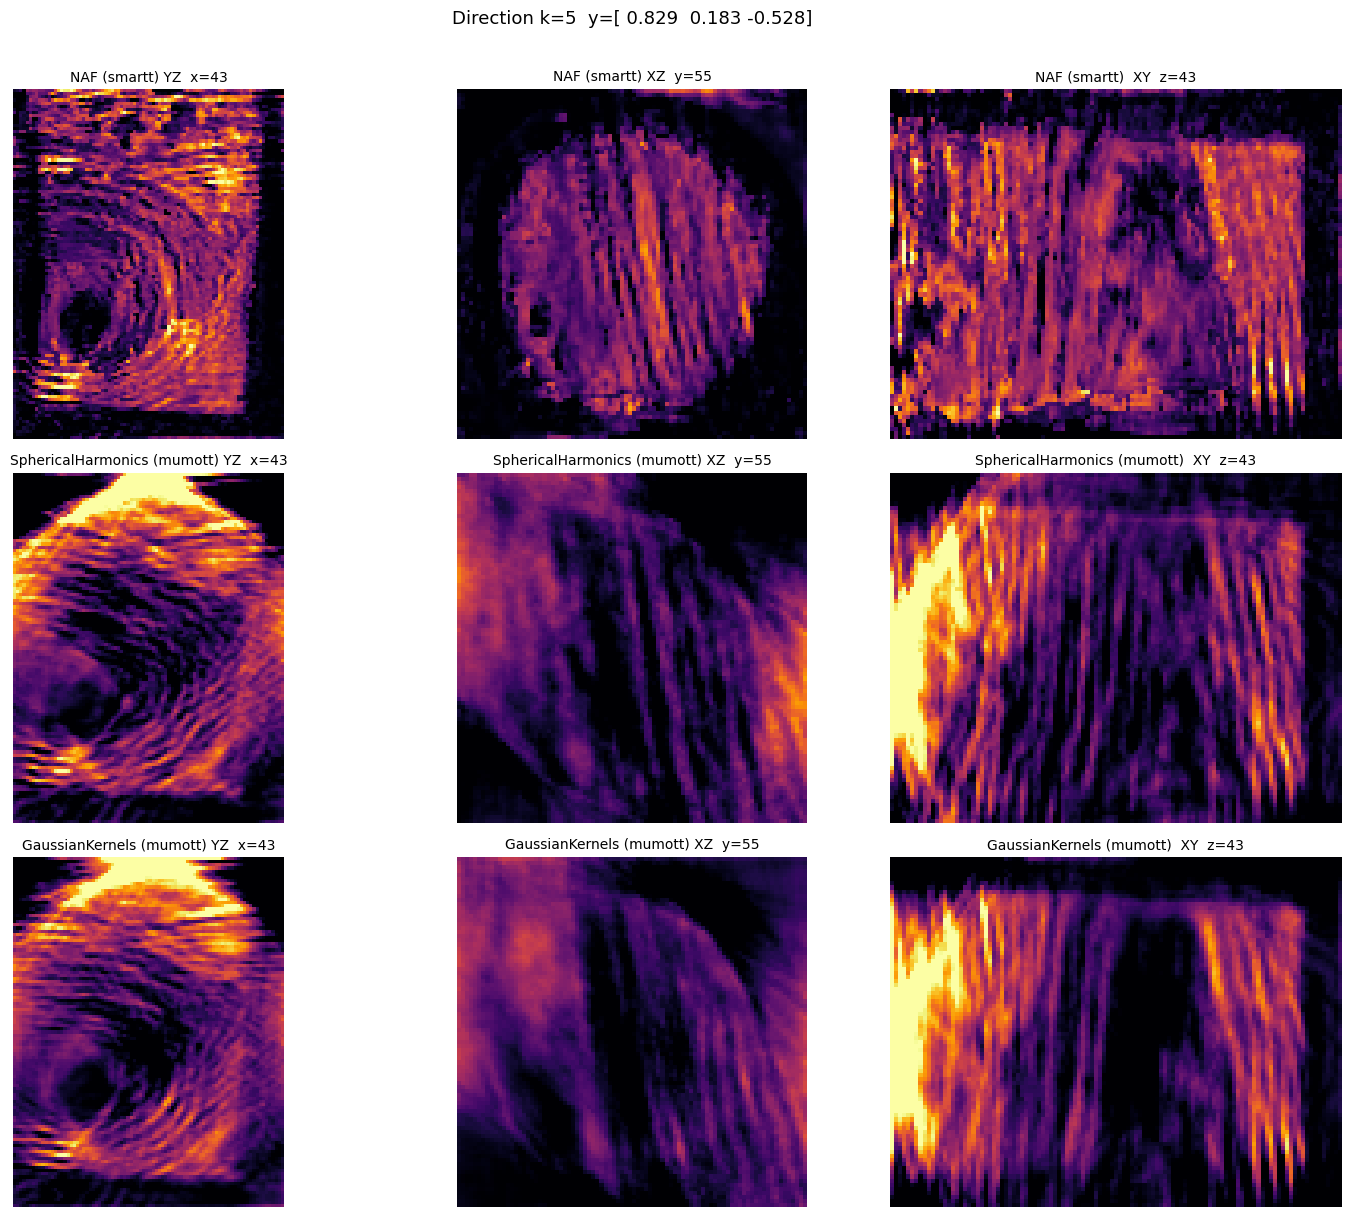

In [75]:
K_INSPECT = 5 # change to inspect a different direction

r_fbp_k = recon_fbp_np[K_INSPECT]
vmin_k  = r_fbp_k.min()
vmin_k = 0
vmax_k  = np.percentile(r_fbp_k, 99)

fig, axes = plt.subplots(n_methods, 3, figsize=(15, 4 * n_methods))
for row, (name, recon) in enumerate(reconstructions.items()):
    vol    = recon[K_INSPECT]
    slices = [vol[mid_x, :, :], vol[:, mid_y, :], vol[:, :, mid_z]]
    titles = [f'{name} YZ  x={mid_x}', f'{name} XZ  y={mid_y}', f'{name}  XY  z={mid_z}']
    for col, (sl, title) in enumerate(zip(slices, titles)):
        im = axes[row, col].imshow(sl, cmap='inferno', vmin=vmin_k, vmax=vmax_k)
        axes[row, col].axis('off')
        axes[row, col].set_title(title, fontsize=10)
    axes[row, 0].set_ylabel(name, fontsize=10)
    

# plt.colorbar(im, ax=axes[:, 2], shrink=0.5, label='Intensity')
plt.suptitle(
    f'Direction k={K_INSPECT}  y={np.round(y_directions[K_INSPECT], 3)}',
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

### 5.3 Difference maps (method − FBP)

Diverging colour map centred at zero; symmetric limits at the 98th percentile of |diff|.
Blue = method gives less intensity than FBP; red = more.

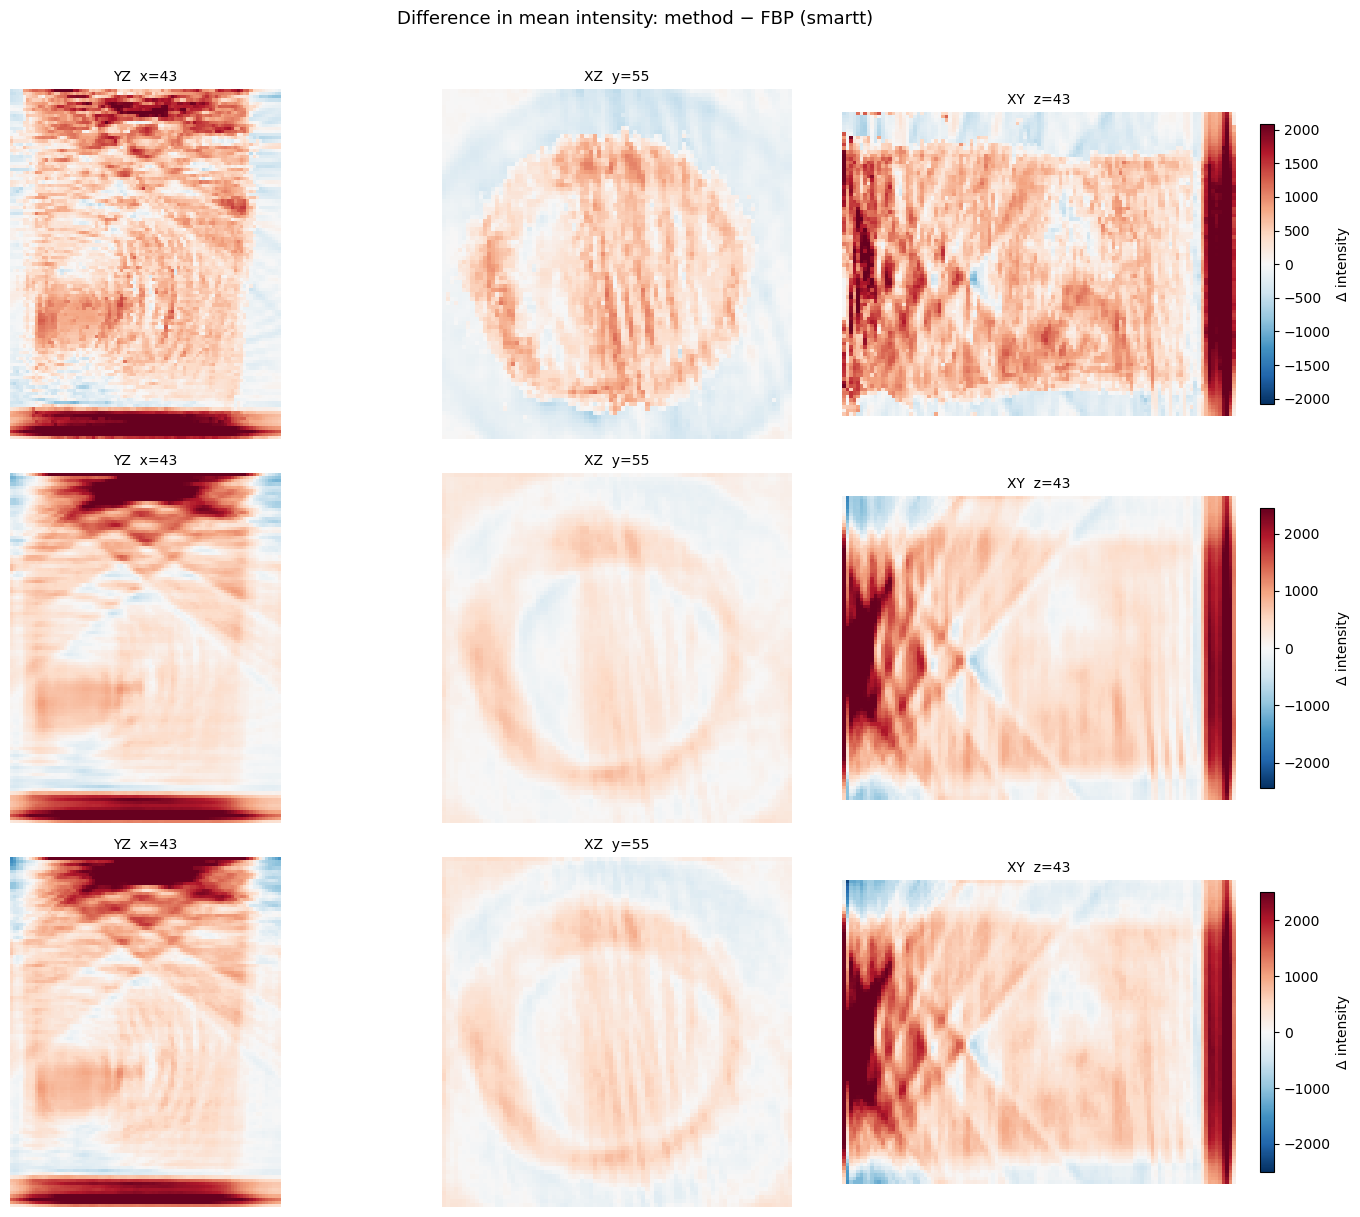

In [71]:
others = {k: v for k, v in reconstructions.items() if k != 'FBP (smartt)'}
n_others = len(others)

fig, axes = plt.subplots(n_others, 3, figsize=(15, 4 * n_others))
if n_others == 1:
    axes = axes[np.newaxis]

for row, (name, recon) in enumerate(others.items()):
    diff   = recon.mean(axis=0) - mean_fbp
    absmax = np.percentile(np.abs(diff), 98)
    slices = [diff[mid_x, :, :], diff[:, mid_y, :], diff[:, :, mid_z]]
    titles = [f'YZ  x={mid_x}', f'XZ  y={mid_y}', f'XY  z={mid_z}']
    for col, (sl, title) in enumerate(zip(slices, titles)):
        im = axes[row, col].imshow(sl, cmap='RdBu_r', vmin=-absmax, vmax=absmax)
        axes[row, col].axis('off')
        axes[row, col].set_title(title, fontsize=10)
    axes[row, 0].set_ylabel(f'{name}\n− FBP', fontsize=9)
    plt.colorbar(im, ax=axes[row, 2], shrink=0.8, label='Δ intensity')

plt.suptitle('Difference in mean intensity: method − FBP (smartt)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 5.4 Missing-cone visualisation in Fourier space

For a sub-CT at direction `y_k`, only beams orthogonal to `y_k` are used.  Fourier frequencies
along `y_k` have no contributing projections and remain unrecovered — the *missing cone*.
This appears as suppressed power (dark stripes) in the log-magnitude FFT of the sub-volume.

Iterative methods (NN, SH, GK) are expected to exhibit the same cone unless explicitly
constrained; FBP is particularly prone to streak artefacts from missing frequencies.

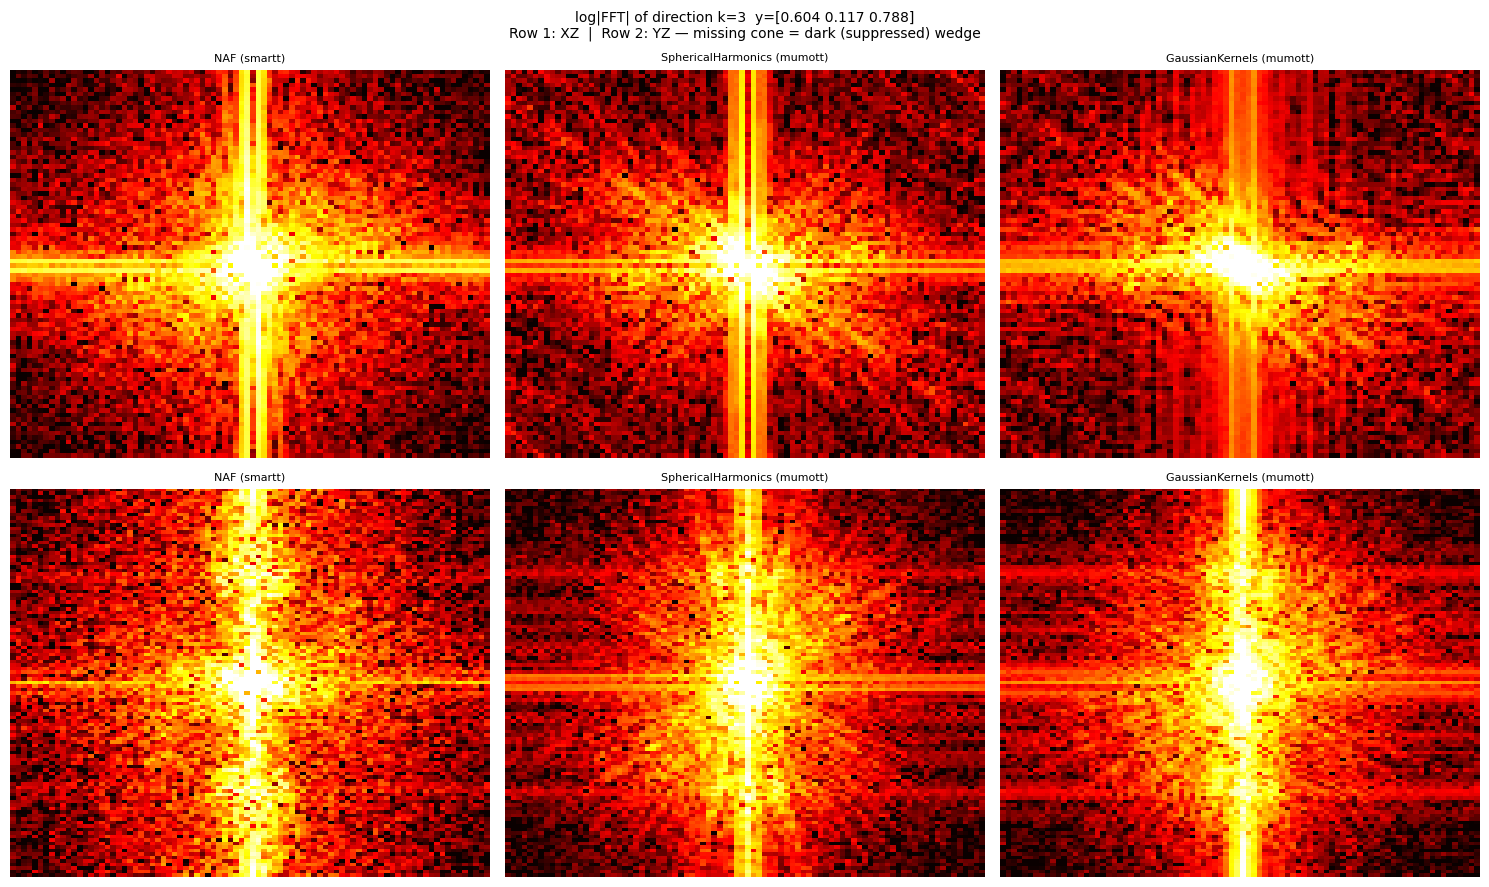

In [72]:
# Log-magnitude FFT central slices for direction K_INSPECT
fig, axes = plt.subplots(2, n_methods, figsize=(5 * n_methods, 9))

for col, (name, recon) in enumerate(reconstructions.items()):
    vol_k   = recon[K_INSPECT].astype(np.float32)
    fft_vol = np.abs(np.fft.fftshift(np.fft.fftn(vol_k)))
    log_fft = np.log1p(fft_vol)
    fx, fy, fz = [s // 2 for s in fft_vol.shape]

    # Row 0: XZ plane (kx–kz), Row 1: YZ plane (ky–kz)
    for row, (sl, ylabel) in enumerate([
        (log_fft[:, fy, :], 'kx'),
        (log_fft[fx, :, :], 'ky'),
    ]):
        axes[row, col].imshow(sl, cmap='hot', aspect='auto',
                              vmin=np.percentile(sl, 5), vmax=np.percentile(sl, 99))
        axes[row, col].set_xlabel('kz', fontsize=8)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(ylabel, fontsize=8)
        axes[row, col].set_title(name, fontsize=8, wrap=True)

plt.suptitle(
    f'log|FFT| of direction k={K_INSPECT}  y={np.round(y_directions[K_INSPECT], 3)}\n'
    'Row 1: XZ  |  Row 2: YZ — missing cone = dark (suppressed) wedge',
    fontsize=10,
)
plt.tight_layout()
plt.show()

### 5.5 Per-direction mean intensity profile

For each direction k, the spatially-averaged intensity gives a scalar measure of how much
scattering power was reconstructed in that direction.  Comparing profiles across methods
reveals systematic biases (e.g. over-smoothing in SH at high-k directions).

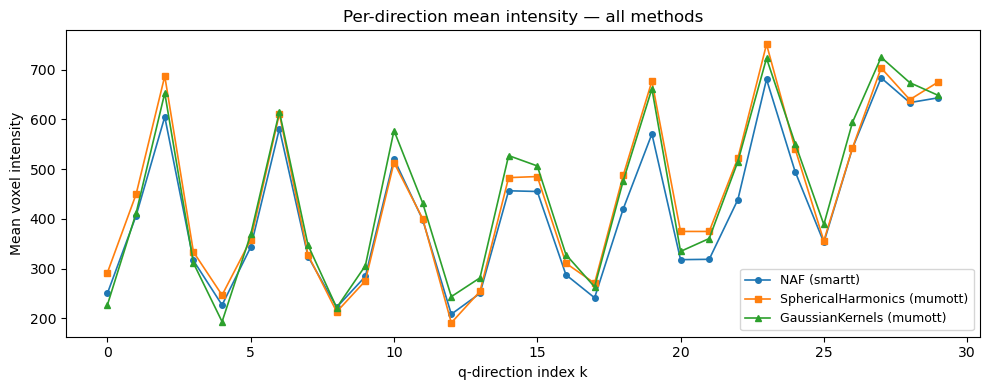

In [73]:
fig, ax = plt.subplots(figsize=(10, 4))
markers = ['o', 's', '^', 'D']
for (name, recon), marker in zip(reconstructions.items(), markers):
    profile = recon.mean(axis=(1, 2, 3))   # (K,) — mean over voxels
    ax.plot(range(K), profile, marker=marker, markersize=4, label=name, linewidth=1.2)

ax.set_xlabel('q-direction index k')
ax.set_ylabel('Mean voxel intensity')
ax.set_title('Per-direction mean intensity — all methods')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [85]:
import ipywidgets as widgets
from ipywidgets import interact
from matplotlib.lines import Line2D

_crosshair_handles = [Line2D([], [], color=c, lw=1.5)
                      for c in ['limegreen', 'tomato', 'deepskyblue']]
_crosshair_labels  = ['x', 'y', 'z']


def _make_rt_viewer(rt_volumes, ref_volume, sphere_mask, directions):
    K_, X_, Y_, Z_ = ref_volume.shape

    # Color scale anchored to NAF sphere interior (fixed across all dropdown options)
    mean_ref = ref_volume.mean(axis=0)
    _abs_lo  = float(np.percentile(mean_ref[sphere_mask], 0.5))
    _abs_hi  = float(np.percentile(mean_ref[sphere_mask], 99.5))
    _diff_lim = 0.15 * (_abs_hi - _abs_lo)

    options = {'NAF': ref_volume}
    options.update({f'{l}': v for l, v in rt_volumes.items()})
    keys = list(options.keys())

    # Pre-extract sphere interiors once for speed.
    interiors = [ref_volume[k_][sphere_mask].ravel() for k_ in range(K_)]
    all_vals  = np.concatenate(interiors)
    bins = np.linspace(np.percentile(all_vals, 0.5), np.percentile(all_vals, 99.5), 80)

    def _view(dataset, show_difference, k, x, y, z):
        vol   = options[dataset]
        vol_k = vol[k]

        if show_difference and dataset != 'NAF':
            data   = vol_k - ref_volume[k]
            cmap   = 'RdBu_r'
            lo, hi = -_diff_lim, _diff_lim
            clabel = 'Recons − NAF'
        else:
            data   = vol_k
            cmap   = 'inferno'
            # lo, hi = _abs_lo, _abs_hi
            lo = min(float(np.percentile(mean_ref[x, :, :], 0.5)), float(np.percentile(mean_ref[:, y, :], 0.5)), float(np.percentile(mean_ref[:, :, z], 0.5)))
            hi = max(float(np.percentile(mean_ref[x, :, :], 99.5)), float(np.percentile(mean_ref[:, y, :], 99.5)), float(np.percentile(mean_ref[:, :, z], 99.5)))
            clabel = 'Intensity'

        lo = min(float(np.percentile(mean_ref[x, :, :], 0.5)), float(np.percentile(mean_ref[:, y, :], 0.5)), float(np.percentile(mean_ref[:, :, z], 0.5)))
        hi = max(float(np.percentile(mean_ref[x, :, :], 99.5)), float(np.percentile(mean_ref[:, y, :], 99.5)), float(np.percentile(mean_ref[:, :, z], 99.5)))

        fig = plt.figure(figsize=(13, 9))
        gs  = fig.add_gridspec(1, 3, height_ratios=[1], hspace=0.45, wspace=0.3)
        # gs  = fig.add_gridspec(1, 3, height_ratios=[1, 0.65], hspace=0.45, wspace=0.3)
        ax_yz   = fig.add_subplot(gs[0, 0])
        ax_xz   = fig.add_subplot(gs[0, 1])
        ax_xy   = fig.add_subplot(gs[0, 2])
        # ax_hist = fig.add_subplot(gs[1, :])
        

        kw = dict(cmap=cmap, vmin=lo, vmax=hi, aspect='equal', origin='lower')

        # YZ plane (x fixed) — Y horizontal, Z vertical
        im = ax_yz.imshow(data[x, :, :].T, **kw)
        ax_yz.axvline(y, color='tomato',      lw=0.9, alpha=0.85)
        ax_yz.axhline(z, color='deepskyblue', lw=0.9, alpha=0.85)
        ax_yz.set_title(f'YZ  (x={x})')
        ax_yz.set_xlabel('Y')
        ax_yz.set_ylabel('Z')

        # XZ plane (y fixed) — X horizontal, Z vertical
        ax_xz.imshow(data[:, y, :].T, **kw)
        ax_xz.axvline(x, color='limegreen',   lw=0.9, alpha=0.85)
        ax_xz.axhline(z, color='deepskyblue', lw=0.9, alpha=0.85)
        ax_xz.set_title(f'XZ  (y={y})')
        ax_xz.set_xlabel('X')
        ax_xz.set_ylabel('Z')

        # XY plane (z fixed) — X horizontal, Y vertical
        ax_xy.imshow(data[:, :, z].T, **kw)
        ax_xy.axvline(x, color='limegreen', lw=0.9, alpha=0.85)
        ax_xy.axhline(y, color='tomato',    lw=0.9, alpha=0.85)
        ax_xy.set_title(f'XY  (z={z})')
        ax_xy.set_xlabel('X')
        ax_xy.set_ylabel('Y')

        ax_xy.legend(_crosshair_handles, _crosshair_labels,
                     fontsize=7, loc='lower right', framealpha=0.5, title='slice pos.')
        plt.colorbar(im, ax=[ax_yz, ax_xz, ax_xy], shrink=0.65, label=clabel)

        # # Histogram: sphere-interior distributions for all K overlaid.
        # # Always uses raw vol (not diff) so we see actual intensities regardless
        # # of the show_difference toggle — normalization diagnostic is about the
        # # raw scale, not residuals.
        # vol_interiors = [vol[k_][sphere_mask].ravel() for k_ in range(K_)]

        # for k_ in range(K_):
        #     ax_hist.hist(
        #         vol_interiors[k_], bins=bins, histtype='step',
        #         color='steelblue' if k_ == k else 'gray',
        #         lw=1.8        if k_ == k else 0.5,
        #         alpha=1.0     if k_ == k else 0.25,
        #         label=f'k={k_} (selected)' if k_ == k else '_nolegend_',
        #     )

        # mu    = float(np.mean(vol_interiors[k]))
        # sigma = float(np.std(vol_interiors[k]))
        # ax_hist.axvline(mu,         color='steelblue', lw=1.5, ls='--',
        #                 label=f'μ = {mu:.3g}')
        # ax_hist.axvline(mu - sigma, color='steelblue', lw=1.0, ls=':',
        #                 label=f'σ = {sigma:.3g}')
        # ax_hist.axvline(mu + sigma, color='steelblue', lw=1.0, ls=':')
        # # Colourscale limits — if distributions are far outside these, the
        # # colourmap is clipping and normalization may be mismatched across K.
        # ax_hist.axvline(_abs_lo, color='orange', lw=1.2, ls='--', alpha=0.8,
        #                 label='cmap lo / hi')
        # ax_hist.axvline(_abs_hi, color='orange', lw=1.2, ls='--', alpha=0.8)

        # ax_hist.set_xlabel('Voxel intensity (sphere interior)')
        # ax_hist.set_ylabel('Count')
        # ax_hist.set_title(
        #     f'Sphere-interior distributions — all K overlaid  '
        #     f'(highlighted: k={k},  μ={mu:.3g},  σ={sigma:.3g})'
        # )
        # ax_hist.legend(fontsize=8)

        # plt.suptitle(
        #     f'{dataset}  |  k={k}  y_dir={np.round(directions[k], 2)}',
        #     fontsize=11,
        # )
        plt.show()

    interact(
        _view,
        dataset=widgets.Dropdown(
            options=keys, value=keys[0], description='Volume:',
            style={'description_width': 'initial'},
        ),
        show_difference=widgets.Checkbox(value=False, description='Diff from NAF'),
        k=widgets.IntSlider(min=0, max=K_-1, step=1, value=0,
                            description='k (dir)', continuous_update=False),
        x=widgets.IntSlider(min=0, max=X_-1, step=1, value=X_//2,
                            description='x', continuous_update=False),
        y=widgets.IntSlider(min=0, max=Y_-1, step=1, value=Y_//2,
                            description='y', continuous_update=False),
        z=widgets.IntSlider(min=0, max=Z_-1, step=1, value=Z_//2,
                            description='z', continuous_update=False),
    )

keys = [k for k in reconstructions]

_make_rt_viewer({k:reconstructions[k] for k in keys[1:]}, reconstructions[keys[0]], None, y_directions)


interactive(children=(Dropdown(description='Volume:', options=('NAF', 'SphericalHarmonics (mumott)', 'Gaussian…

## 6. Principal Orientation from SH Reconstruction

Uses `SphericalHarmonics.get_output()` to extract the principal eigenvector of the ODF at each
voxel, then visualises its z-component as a proxy for the orientation of the dominant scattering
direction relative to the XY plane.

- z-component ≈ 0  → fibre lies in the XY plane (in-plane)
- z-component ≈ ±1 → fibre points along Z (out-of-plane)

**NAF (smartt)** and **SphericalHarmonics (mumott)** are shown side-by-side — both use the same
SH band limit (`ell_max=8`) so any difference reflects the two optimisation strategies.

In [86]:
# Fresh SphericalHarmonics without probed_coordinates — only needed for get_output()
_basis_orient = SphericalHarmonics(ell_max=SH_ELL_MAX)

_out_naf = _basis_orient.get_output(coeffs_naf)  # coeffs_naf: (X, Y, Z, C)
_out_sh  = _basis_orient.get_output(coeffs_sh)   # coeffs_sh:  (X, Y, Z, C)

dirs_naf = torch.FloatTensor(_out_naf.eigenvector_1)  # (X, Y, Z, 3)
dirs_sh  = torch.FloatTensor(_out_sh.eigenvector_1)   # (X, Y, Z, 3)

print(f'Principal direction shape: {dirs_naf.shape}  (X, Y, Z, 3)')

Principal direction shape: torch.Size([86, 111, 86, 3])  (X, Y, Z, 3)


In [ ]:
import ipywidgets as widgets
from ipywidgets import interact

_z_hat   = torch.tensor([0., 0., 1.])
_X_shape = dirs_naf.shape[0]

@interact(x_slice=widgets.IntSlider(
    min=0, max=_X_shape - 1, step=1, value=_X_shape // 2,
    description='x slice', continuous_update=False,
))
def show_principal_orientation(x_slice):
    """Z-component of the principal SH direction in the YZ plane at a given x."""
    naf_z = (dirs_naf[x_slice] @ _z_hat).numpy()  # (Y, Z)
    sh_z  = (dirs_sh[x_slice]  @ _z_hat).numpy()  # (Y, Z)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    im0 = axes[0].imshow(naf_z.T, cmap='viridis', vmin=0, vmax=1, origin='lower')
    axes[0].set_title(f'NAF (smartt) — x={x_slice}')
    axes[0].set_xlabel('Y')
    axes[0].set_ylabel('Z')
    plt.colorbar(im0, ax=axes[0], fraction=0.046, label='z-component')

    im1 = axes[1].imshow(sh_z.T, cmap='viridis', vmin=0, vmax=1, origin='lower')
    axes[1].set_title(f'SphericalHarmonics (mumott) — x={x_slice}')
    axes[1].set_xlabel('Y')
    axes[1].set_ylabel('Z')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, label='z-component')

    plt.suptitle(
        'Principal SH direction · ẑ\n'
        '≈ 0 → in-plane (XY)  |  ≈ ±1 → out-of-plane (along Z)',
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=43, continuous_update=False, description='x slice', max=85), Output()), …